In this exercise, we will generate simulated data, and will then use
this data to perform forward and backward stepwise selection.

In [11]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

(a) Create a random number generator and use its normal() method
to generate a predictor X of length n = 100, as well as a noise
vector ϵ of length n = 100.

In [3]:
n = 100

rng = np.random.default_rng(seed=42)

X = rng.normal(loc = 0, scale= 1.0,size = n)

epsilon = rng.normal(scale=0.5, size=n)

(b) Generate a response vector Y of length n = 100 according to the model
$$ Y = \beta_{0} + \beta_{1}X + \beta_{2}X^{2} + \beta_{3}X^{3} +\epsilon$$

where $\beta_{0}$, $\beta_{1}$, $\beta_{2}$, and $\beta_{3}$ are constants of your choice.

In [4]:
beta_0 = 1
beta_1 = 2
beta_2 = 3
beta_3 = 4
Y = (beta_0 + beta_1 * X + beta_2 * X**2 + beta_3 * X**3 + epsilon)

(c) Use forward stepwise selection in order to select a model containing the predictors $X$, $X^2$, . . . , $X^{10}$. What is the model obtained
according to $C_{p}$? Report the coefficients of the model obtained.

In [7]:
# 1. 建立一個 DataFrame
data = pd.DataFrame({'Y': Y, 'X': X})

# 2. 加入 X^2 到 X^10
for i in range(2, 11):
    data[f'X^{i}'] = X ** i

# 現在 data 裡面會有 Y, X, X^2, ..., X^10
# 定義 Predictors (特徵) 和 Response (目標)
X_cols = [col for col in data.columns if col != 'Y']
X_full = data[X_cols]
Y_full = data['Y']

# 1. 加上截距項 (Intercept)，這很重要，statsmodels 不會自動加
X_with_const = sm.add_constant(X_full)

# 2. 擬合 Full Model (包含所有 10 個變數)
full_model = sm.OLS(Y, X_with_const).fit()

# 3. 取得 sigma_hat_squared (全模型的 MSE)
# full_model.mse_resid 就是 RSS / (n - p - 1)
sigma_hat_sq = full_model.mse_resid 

n = len(Y) # 樣本數 100

In [8]:
selected_features = []
remaining_features = list(X_full.columns)
model_results = []

for i in range(1, 11):
    best_rss = float('inf')
    best_feature = None
    
    for feature in remaining_features:
        current_features = selected_features + [feature]
        X_current = sm.add_constant(X_full[current_features])
        model = sm.OLS(Y, X_current).fit()
        
        if model.ssr < best_rss :
            best_rss = model.ssr
            best_feature = feature
    
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    # 計算 Cp 值
    d = i + 1
    Cp = (best_rss / sigma_hat_sq) - (n - 2 * d)
    model_results.append({'i': i, 'Cp': Cp, 'features': list(selected_features), 'RSS': best_rss, 'coefficients': model.params})
    print(f"Step {i}: Added {best_feature}, Cp = {Cp:.4f}")

# 1. 找出 Cp 最小的那一組紀錄
best_result = min(model_results, key=lambda x: x['Cp'])

print(f"最佳變數組合: {best_result['features']}")

# 2. 用這組變數重新跑一次回歸，為了看係數
# 記得要把變數拿出來，並加上常數項
best_features = best_result['features']
X_best = sm.add_constant(X_full[best_features])

final_model = sm.OLS(Y, X_best).fit()

# 3. 印出係數 (這就是題目要的 Report coefficients)
print("\n--- Final Model Coefficients ---")
print(final_model.params)

# 如果你想看更詳細的報表 (包含 p-value, R-squared 等)
print(final_model.summary())

Step 1: Added X^3, Cp = 2278.7463
Step 2: Added X^2, Cp = 356.3238
Step 3: Added X, Cp = 2.8733
Step 4: Added X^9, Cp = 4.0732
Step 5: Added X^5, Cp = 5.3973
Step 6: Added X^8, Cp = 7.1439
Step 7: Added X^7, Cp = 8.2236
Step 8: Added X^4, Cp = 10.0716
Step 9: Added X^10, Cp = 9.4378
Step 10: Added X^6, Cp = 11.0000
最佳變數組合: ['X^3', 'X^2', 'X']

--- Final Model Coefficients ---
const    1.058333
X^3      4.047004
X^2      2.902686
X        1.961738
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:                     8588.
Date:                Fri, 21 Nov 2025   Prob (F-statistic):          1.73e-116
Time:                        20:17:57   Log-Likelihood:                -67.893
No. Observations:                 100   AIC:                

The model obtained via stepwise selection is: $$Y = 1.058333 + 1.961738X + 2.902686X^2 + 4.047004X^3$$

Comparing this to the true underlying model: $$Y = 1 + 2X + 3X^2 + 4X^3 + \epsilon$$

We can see that the method successfully identified the correct subset of predictors (features) and excluded the noise variables ($X^4$ through $X^{10}$). The estimated coefficients are very close to the true values, demonstrating the effectiveness of the stepwise selection method in this scenario."

(d) Repeat (c), using backwards stepwise selection. How does your
answer compare to the results in (c)?

In [10]:
# 一開始包含全部變數
selected_features = list(X_full.columns)
model_results = []


# 我們要一路踢到剩 0 個變數為止 (如果你想保留至少一個，range 可以改)
# 這裡 range(10) 代表會踢 10 次
for i in range(10):
    best_rss = float('inf')
    worst_feature = None
    
    # --- 內層迴圈：尋找踢掉誰最不痛 (RSS 最小) ---
    for feature in selected_features:
        # 暫時移除這個 feature
        current_features = [f for f in selected_features if f != feature]
        
        X_current = sm.add_constant(X_full[current_features])
        model = sm.OLS(Y, X_current).fit()
        
        if model.ssr < best_rss:
            best_rss = model.ssr
            worst_feature = feature
    
    # --- 這一輪結束，正式踢人 ---
    selected_features.remove(worst_feature)

    # 計算 Cp 值
    # d = 目前剩下的變數數量 + 1 (截距項)
    d = len(selected_features) + 1
    
    # Cp 公式: RSS/sigma^2 + 2d - n
    Cp = (best_rss / sigma_hat_sq) + 2 * d - n
    
    model_results.append({
        'step': i+1, 
        'Cp': Cp, 
        'features': list(selected_features), # 記得複製 list
        'RSS': best_rss
    })
    
    print(f"Step {i+1}: removed {worst_feature}, remaining d={d}, Cp = {Cp:.4f}")

# ---------------------------------------------------------
# 1. 找出 Cp 最小的那一組紀錄
best_result = min(model_results, key=lambda x: x['Cp'])

print("-" * 30)
print(f"最佳變數組合 (by Cp): {best_result['features']}")
print(f"最低 Cp: {best_result['Cp']:.4f}")

# 2. 用這組變數重新跑一次回歸
best_features = best_result['features']
X_best = sm.add_constant(X_full[best_features])

final_model = sm.OLS(Y, X_best).fit()

# 3. 印出係數
print("\n--- Final Backward Model Coefficients ---")
print(final_model.params)
print(final_model.summary())

Step 1: removed X^4, remaining d=10, Cp = 9.1199
Step 2: removed X^5, remaining d=9, Cp = 9.6652
Step 3: removed X^10, remaining d=8, Cp = 8.8409
Step 4: removed X^6, remaining d=7, Cp = 6.8654
Step 5: removed X^8, remaining d=6, Cp = 5.4038
Step 6: removed X^7, remaining d=5, Cp = 4.0732
Step 7: removed X^9, remaining d=4, Cp = 2.8733
Step 8: removed X, remaining d=3, Cp = 356.3238
Step 9: removed X^2, remaining d=2, Cp = 2278.7463
Step 10: removed X^3, remaining d=1, Cp = 25458.3393
------------------------------
最佳變數組合 (by Cp): ['X', 'X^2', 'X^3']
最低 Cp: 2.8733

--- Final Backward Model Coefficients ---
const    1.058333
X        1.961738
X^2      2.902686
X^3      4.047004
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.996
Model:                            OLS   Adj. R-squared:                  0.996
Method:                 Least Squares   F-statistic:          

The model obtained via stepwise selection is: $$Y = 1.058333 + 1.961738X + 2.902686X^2 + 4.047004X^3$$

This result is identical to the one obtained in (c). This demonstrates that, in this case, both forward and backward selection identified the same subset of predictors. Furthermore, since both models were fitted on the same dataset using the same features, the estimated coefficients are mathematically guaranteed to be identical.

(e) Now fit a lasso model to the simulated data, again using $X$, $X^2$,. . . , $X^{10}$ as predictors. Use cross-validation to select the optimal
value of λ. Create plots of the cross-validation error as a function
of λ. Report the resulting coefficient estimates, and discuss the
results obtained.

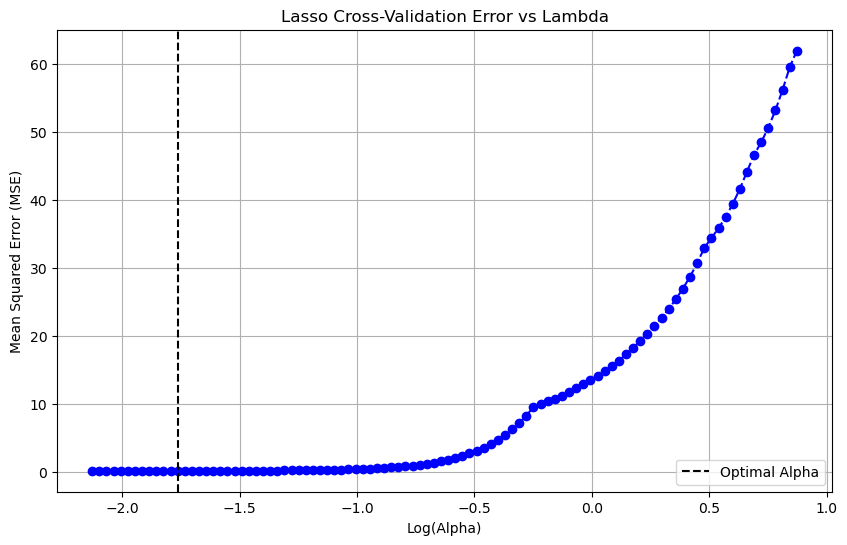

最佳 Lambda (Alpha): 0.017228693120368538

--- Lasso Coefficients (Standardized) ---
  Feature  Coefficient
0       X     1.502047
1     X^2     2.293685
2     X^3     6.563656
3     X^4     0.000000
4     X^5     0.000000
5     X^6     0.000000
6     X^7     0.000000
7     X^8     0.000000
8     X^9     0.000000
9    X^10     0.000000


In [ ]:
# 1. 數據標準化 (Standardization) - Lasso 必做！
# 我們把 X 到 X^10 全部縮放到 mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full) # X_full 是你之前建立包含 X~X^10 的 DataFrame

# 2. 建立並擬合 LassoCV 模型
# cv=10: 題目要求的 Cross-Validation
# max_iter=10000: 增加迭代次數，避免還沒收斂就停下來
lasso_cv = LassoCV(cv=10, random_state=42, max_iter=100000)
lasso_cv.fit(X_scaled, Y)

# 3. 畫出 Cross-Validation Error vs Lambda (Alpha)
# LassoCV 會嘗試很多不同的 alpha，我們把它畫出來
alphas = lasso_cv.alphas_
mse_mean = lasso_cv.mse_path_.mean(axis=1) # 算出每次 CV 的平均誤差

plt.figure(figsize=(10, 6))
plt.plot(np.log10(alphas), mse_mean, linestyle='--', marker='o', color='b')
plt.axvline(np.log10(lasso_cv.alpha_), linestyle='--', color='k', label='Optimal Alpha')
plt.xlabel('Log(Alpha)') # 通常用 Log 座標看比較清楚
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Lasso Cross-Validation Error vs Lambda')
plt.legend()
plt.grid(True)
plt.show()

# 4. 報告結果
print(f"最佳 Lambda (Alpha): {lasso_cv.alpha_}")
print("\n--- Lasso Coefficients (Standardized) ---")

coef_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Coefficient': lasso_cv.coef_
})
print(coef_df)

The Lasso model (fitted on standardized data) resulted in the equation:$$Y = 1.502X + 2.294X^2 + 6.564X^3$$Note that the coefficients for $X^4$ through $X^{10}$ were reduced to zero.This model was obtained with an optimal $\lambda \approx 0.017$. The cross-validation plot shows that for $\lambda < 0.1$, the MSE remains low, indicating that a mild penalty effectively identifies the correct features. However, as $\lambda$ increases from 0.1 to 1, the MSE grows rapidly. This indicates that the penalty becomes too strong, forcing the model to discard important features ($X, X^2, X^3$) and leading to underfitting.

(f) Now generate a response vector Y according to the model $Y= \beta_0 + \beta_7X^7 + \epsilon$,
and perform forward stepwise selection and the lasso. Discuss
the results obtained.

In [15]:
n = 100

rng = np.random.default_rng(seed=42)

X = rng.normal(loc = 0, scale= 1.0,size = n)

epsilon = rng.normal(scale=0.5, size=n)

beta_0 = 5
beta_7 = 20
Y = (beta_0 + beta_7 * X**7 + epsilon)

# 1. 建立一個 DataFrame
data = pd.DataFrame({'Y': Y, 'X': X})

# 2. 加入 X^2 到 X^10
for i in range(2, 11):
    data[f'X^{i}'] = X ** i

# 現在 data 裡面會有 Y, X, X^2, ..., X^10
# 定義 Predictors (特徵) 和 Response (目標)
X_cols = [col for col in data.columns if col != 'Y']
X_full = data[X_cols]
Y_full = data['Y']

# 1. 加上截距項 (Intercept)，這很重要，statsmodels 不會自動加
X_with_const = sm.add_constant(X_full)

# 2. 擬合 Full Model (包含所有 10 個變數)
full_model = sm.OLS(Y, X_with_const).fit()

# 3. 取得 sigma_hat_squared (全模型的 MSE)
# full_model.mse_resid 就是 RSS / (n - p - 1)
sigma_hat_sq = full_model.mse_resid 

n = len(Y) # 樣本數 100

selected_features = []
remaining_features = list(X_full.columns)
model_results = []

for i in range(1, 11):
    best_rss = float('inf')
    best_feature = None
    
    for feature in remaining_features:
        current_features = selected_features + [feature]
        X_current = sm.add_constant(X_full[current_features])
        model = sm.OLS(Y, X_current).fit()
        
        if model.ssr < best_rss :
            best_rss = model.ssr
            best_feature = feature
    
    selected_features.append(best_feature)
    remaining_features.remove(best_feature)

    # 計算 Cp 值
    d = i + 1
    Cp = (best_rss / sigma_hat_sq) - (n - 2 * d)
    model_results.append({'i': i, 'Cp': Cp, 'features': list(selected_features), 'RSS': best_rss, 'coefficients': model.params})
    print(f"Step {i}: Added {best_feature}, Cp = {Cp:.4f}")

# 1. 找出 Cp 最小的那一組紀錄
best_result = min(model_results, key=lambda x: x['Cp'])

print(f"最佳變數組合: {best_result['features']}")

# 2. 用這組變數重新跑一次回歸，為了看係數
# 記得要把變數拿出來，並加上常數項
best_features = best_result['features']
X_best = sm.add_constant(X_full[best_features])

final_model = sm.OLS(Y, X_best).fit()

# 3. 印出係數 (這就是題目要的 Report coefficients)
print("\n--- Final Model Coefficients ---")
print(final_model.params)

# 如果你想看更詳細的報表 (包含 p-value, R-squared 等)
print(final_model.summary())

Step 1: Added X^7, Cp = 2.5994
Step 2: Added X^9, Cp = -0.3456
Step 3: Added X, Cp = 1.4279
Step 4: Added X^10, Cp = 3.2499
Step 5: Added X^5, Cp = 4.8165
Step 6: Added X^3, Cp = 6.4848
Step 7: Added X^4, Cp = 8.2873
Step 8: Added X^8, Cp = 9.3900
Step 9: Added X^6, Cp = 9.0002
Step 10: Added X^2, Cp = 11.0000
最佳變數組合: ['X^7', 'X^9']

--- Final Model Coefficients ---
const     5.020389
X^7      20.038286
X^9      -0.008604
dtype: float64
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.015e+07
Date:                Fri, 21 Nov 2025   Prob (F-statistic):          1.97e-292
Time:                        22:03:30   Log-Likelihood:                -67.246
No. Observations:                 100   AIC:                             140.5
Df Res

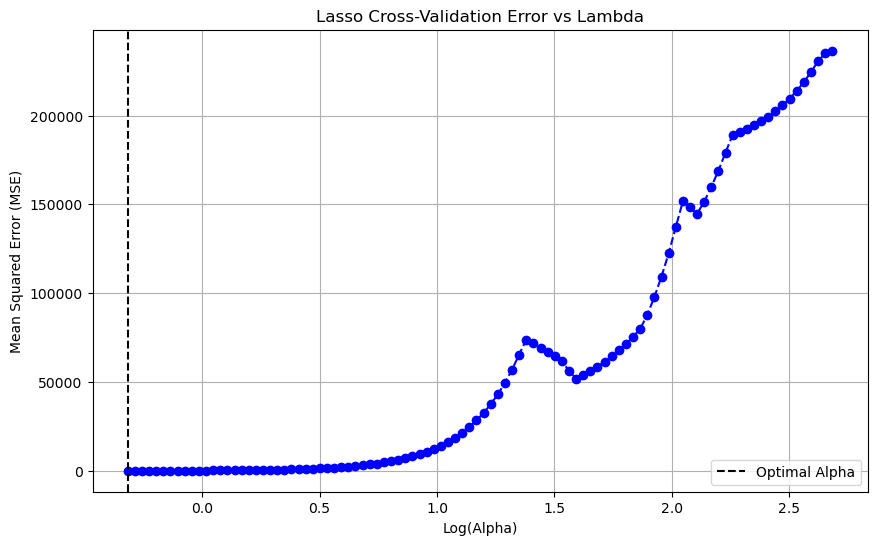

最佳 Lambda (Alpha): 0.48204044656658357

--- Lasso Coefficients (Standardized) ---
  Feature  Coefficient
0       X    -0.000000
1     X^2    -0.000000
2     X^3     0.000000
3     X^4    -0.000000
4     X^5    18.183265
5     X^6    -0.000000
6     X^7   436.533555
7     X^8    -0.000000
8     X^9    27.339708
9    X^10    -0.000000


In [16]:
# 1. 數據標準化 (Standardization) - Lasso 必做！
# 我們把 X 到 X^10 全部縮放到 mean=0, std=1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_full) # X_full 是你之前建立包含 X~X^10 的 DataFrame

# 2. 建立並擬合 LassoCV 模型
# cv=10: 題目要求的 Cross-Validation
# max_iter=10000: 增加迭代次數，避免還沒收斂就停下來
lasso_cv = LassoCV(cv=10, random_state=42, max_iter=100000)
lasso_cv.fit(X_scaled, Y)

# 3. 畫出 Cross-Validation Error vs Lambda (Alpha)
# LassoCV 會嘗試很多不同的 alpha，我們把它畫出來
alphas = lasso_cv.alphas_
mse_mean = lasso_cv.mse_path_.mean(axis=1) # 算出每次 CV 的平均誤差

plt.figure(figsize=(10, 6))
plt.plot(np.log10(alphas), mse_mean, linestyle='--', marker='o', color='b')
plt.axvline(np.log10(lasso_cv.alpha_), linestyle='--', color='k', label='Optimal Alpha')
plt.xlabel('Log(Alpha)') # 通常用 Log 座標看比較清楚
plt.ylabel('Mean Squared Error (MSE)')
plt.title('Lasso Cross-Validation Error vs Lambda')
plt.legend()
plt.grid(True)
plt.show()

# 4. 報告結果
print(f"最佳 Lambda (Alpha): {lasso_cv.alpha_}")
print("\n--- Lasso Coefficients (Standardized) ---")

coef_df = pd.DataFrame({
    'Feature': X_full.columns,
    'Coefficient': lasso_cv.coef_
})
print(coef_df)

For the model $Y = 5 + 20X^7 + \epsilon$, both Forward Stepwise selection and Lasso successfully identified the true predictor $X^7$, but both methods also included extra 'noise' variables ($X^9$ for Stepwise; $X^5, X^9$ for Lasso).This phenomenon is likely due to multicollinearity. High-degree polynomial terms (like $X^5, X^7, X^9$) are highly correlated with each other. This makes it difficult for the algorithms to distinguish perfectly between them based on limited data ($n=100$).However, looking at the coefficients, the coefficient for $X^7$ is significantly larger than the others in both models, confirming that both methods correctly identified $X^7$ as the dominant feature.